In [1]:
import pandas as pd
import geopandas as gpd
import maup
from maup import smart_repair
import time
import os

maup.progress.enabled = True

In [2]:
import matplotlib.pyplot as plt
from gerrychain import Graph, GeographicPartition, Partition, proposals, updaters, constraints, accept, MarkovChain, Election
from gerrychain.updaters import cut_edges, Tally
from gerrychain.proposals import recom, propose_random_flip
from gerrychain.accept import always_accept
from functools import partial
import time

import pandas as pd
import numpy as np
from collections import Counter

In [3]:
sc_df = gpd.read_file("./SC/SC.shp")
sc_df = sc_df.fillna(0)
sc_graph = Graph.from_geodataframe(sc_df, adjacency="rook")

In [4]:
elections = [
    Election("G20PRED", {"Democratic": "G20PRED", "Republican": "G20PRER"}),
]

In [5]:
# return districts won by dems
def get_democratic_wins(partition):
    dem_wins = 0
    
    for district in partition.parts:
        dem_votes = sum(partition.graph.nodes[node]["G20PRED"] for node in partition.parts[district])
        rep_votes = sum(partition.graph.nodes[node]["G20PRER"] for node in partition.parts[district])
        
        if dem_votes > rep_votes:
            dem_wins += 1
            
    return dem_wins

In [6]:
my_updaters = {
    "cut_edges": cut_edges,
    "population": updaters.Tally("TOTPOP", alias="population"),
    "G20PRED": updaters.Tally("G20PRED"),
    "G20PRER": updaters.Tally("G20PRER"),
    "democratic_wins": get_democratic_wins
}

In [7]:
election_updaters = {election.name: election for election in elections}
my_updaters.update(election_updaters)

In [8]:
initial_partition = Partition(sc_graph, assignment="SEND", updaters=my_updaters)

In [9]:
ideal_population = sum(initial_partition["population"].values()) / len(initial_partition)

In [10]:
save_district_graph_mod=1
save_district_plot_mod=100

proposal = partial(recom,
                   pop_col="TOTPOP",
                   pop_target=ideal_population,
                   epsilon=0.10,
                   node_repeats=2
                  )
compactness_bound = constraints.UpperBound(
    lambda p: len(p["cut_edges"]),
    2*len(initial_partition["cut_edges"])
)

pop_constraint = constraints.within_percent_of_ideal_population(initial_partition, 0.10)

In [11]:
# run chain for steps and return data
def run_chain(steps):
    print("chain number of steps: ", steps)
    
    chain = MarkovChain(
        proposal=proposal,
        constraints=[pop_constraint, compactness_bound],
        accept=accept.always_accept,
        initial_state=initial_partition,
        total_steps=steps
    )
    
    cut_edges_count = []
    dem_wins_count = []
    dem_vote_percents = []
    
    for i, partition in enumerate(chain.with_progress_bar()):
        cut_edges_count.append(len(partition["cut_edges"]))
        dem_wins_count.append(partition["democratic_wins"])
        dem_vote_percents.append(sorted(partition["G20PRED"].percents("Democratic")))
    
    return cut_edges_count, dem_wins_count, dem_vote_percents

/opt/homebrew/anaconda3/envs/gerry/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


chain number of steps:  100


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:00<00:00, 125.57it/s]


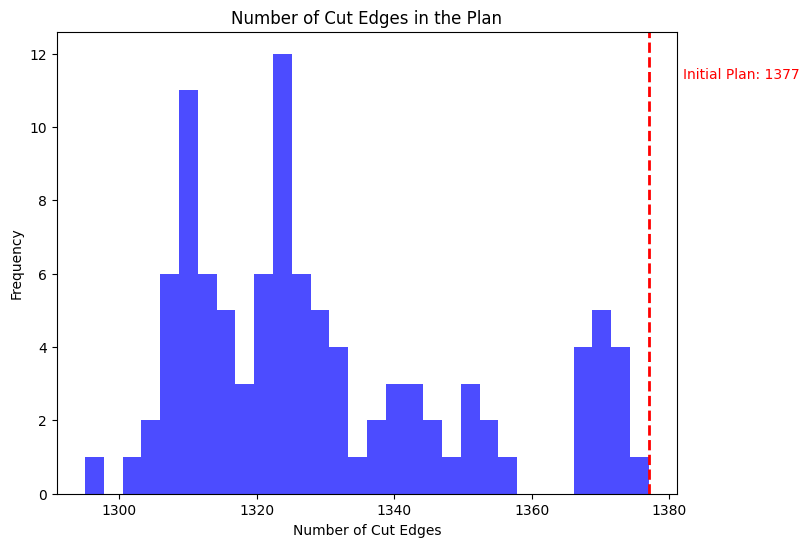

In [12]:
steps = 100
cut_edges_data, dem_wins_data, dem_vote_percent_data = run_chain(steps)

# Plot histogram for cut edges
fig, ax = plt.subplots(figsize=(8, 6))

# Draw the histogram
ax.hist(cut_edges_data, bins=30, color='blue', alpha=0.7)

# Draw a vertical line for the initial plan's cut edges
initial_cut_edges = len(initial_partition["cut_edges"])
ax.axvline(initial_cut_edges, color="red", linestyle="--", linewidth=2)

# Add text annotation for the initial plan's cut edges
ax.text(initial_cut_edges + 5, ax.get_ylim()[1] * 0.9, 
        f"Initial Plan: {initial_cut_edges}", 
        color='red', fontsize=10)

# Annotate
ax.set_title("Number of Cut Edges in the Plan")
ax.set_xlabel("Number of Cut Edges")
ax.set_ylabel("Frequency")

# Save and show
plt.savefig('cut_edges_histogram.png')
plt.show()